# Phase 4 - Supervised Machine Learning

1. **Popularity Regression** - predict Spotify popularity from audio features.
2. **Mood Classification** - infer the four mood classes without using valence or energy as inputs.
3. **Genre Classification** - predict a track genre from audio features alone.

In [1]:
import os
import json
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score
)

sns.set_theme(style='whitegrid')

# Keep the same mood colors used in Phase 3.
mood_order = ['Euphoric', 'Peaceful', 'Aggressive', 'Melancholic']
mood_colors = {
    'Euphoric': '#F4C95D',
    'Peaceful': '#67C6C3',
    'Aggressive': '#E85D5D',
    'Melancholic': '#6C70B5'
}

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

os.makedirs('models/metadata', exist_ok=True)
os.makedirs('reports/figures/04_models', exist_ok=True)
os.makedirs('reports/tables', exist_ok=True)
os.makedirs('reports/models', exist_ok=True)

print('Working folder:', os.getcwd())

Working folder: C:\dev\Moodwave\moodwave-ml


## 1. Load the processed Phase 2 data

In [2]:
# Phase 4 only needs the historical and genre datasets.
if os.path.exists('data/processed/historical_tracks.parquet'):
    historical = pd.read_parquet('data/processed/historical_tracks.parquet')
    genre = pd.read_parquet('data/processed/genre_tracks.parquet')
else:
    historical = pd.read_csv('data/processed/historical_tracks.csv.gz')
    genre = pd.read_csv('data/processed/genre_tracks.csv.gz')

print('Historical:', historical.shape)
print('Genre:', genre.shape)

Historical: (2400, 28)
Genre: (113550, 27)


In [3]:
historical.head()

,playlist_url,year,track_id,track_name,popularity,album_name,artist_id,artist_name,artist_genres,artist_popularity,...,liveness,valence,tempo,duration_ms,time_signature,mood_label,mood_valence_band,mood_energy_band,duration_min,release_decade
0,https://open.spotify.com/playlist/37i9dQZF1DWU...,2000,6naxalmIoLFWR0siv8dnQQ,Oops!...I Did It Again,81,Oops!... I Did It Again,26dSoYclwsYLMAKD3tpOr4,Britney Spears,"['dance pop', 'pop']",81,...,0.3550,0.894,95.053,211160,4,Euphoric,high,high,3.519333,2000
1,https://open.spotify.com/playlist/37i9dQZF1DWU...,2000,2m1hi0nfMR9vdGC8UcrnwU,All The Small Things,83,Enema Of The State,6FBDaR13swtiWwGhX1WQsP,blink-182,"['alternative metal', 'modern rock', 'pop punk...",79,...,0.6120,0.684,148.726,167067,4,Euphoric,high,high,2.784450,2000
2,https://open.spotify.com/playlist/37i9dQZF1DWU...,2000,3y4LxiYMgDl4RethdzpmNe,Breathe,66,Breathe,25NQNriVT2YbSW80ILRWJa,Faith Hill,"['contemporary country', 'country', 'country d...",62,...,0.2510,0.278,136.859,250547,4,Melancholic,low,low,4.175783,2000
3,https://open.spotify.com/playlist/37i9dQZF1DWU...,2000,0v1XpBHnsbkCn7iJ9Ucr1l,It's My Life,81,Crush,58lV9VcRSjABbAbfWS6skp,Bon Jovi,"['glam metal', 'rock']",79,...,0.3470,0.544,119.992,224493,4,Euphoric,high,high,3.741550,2000
4,https://open.spotify.com/playlist/37i9dQZF1DWU...,2000,62bOmKYxYg7dhrC6gH9vFn,Bye Bye Bye,75,No Strings Attached,6Ff53KvcvAj5U7Z1vojB5o,*NSYNC,"['boy band', 'dance pop', 'pop']",70,...,0.0821,0.861,172.638,200400,4,Euphoric,high,high,3.340000,2000


In [4]:
genre.head()

,source_row_id,track_id,artist_name,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,valence,tempo,time_signature,track_genre,mood_label,mood_valence_band,mood_energy_band,duration_min,genre_count,is_single_genre_track
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,0.715,87.917,4,acoustic,Peaceful,high,low,3.844433,4,False
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,0.267,77.489,4,acoustic,Melancholic,low,low,2.493500,2,False
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,0.120,76.332,4,acoustic,Melancholic,low,low,3.513767,1,True
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,0.143,181.740,3,acoustic,Melancholic,low,low,3.365550,1,True
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,0.167,119.949,4,acoustic,Melancholic,low,low,3.314217,1,True


## 2. Common audio features

For models described as using **audio characteristics alone**, names, IDs, artist information and album information are not used as predictors.

In [5]:
audio_features = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature'
]

print(audio_features)

['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature']


# Part A - Popularity Regression

The target is `popularity`. The same song can appear in more than one historical year, so we first keep one row per `track_id`. This prevents the same song from appearing in both training and testing data.

In [6]:
regression_data = historical.drop_duplicates(subset='track_id').copy()

print('Historical rows:', len(historical))
print('Unique tracks used for regression:', len(regression_data))
print('Duplicate tracks removed:', len(historical) - len(regression_data))

Historical rows: 2400
Unique tracks used for regression: 2302
Duplicate tracks removed: 98


In [7]:
X = regression_data[audio_features]
y = regression_data['popularity']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (2302, 13)
y shape: (2302,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 1841
Testing rows: 461


### A1. Baseline regression

The baseline always predicts the average popularity from the training set. Our Linear Regression should ideally improve on this simple guess.

In [9]:
baseline_regression = DummyRegressor(strategy='mean')
baseline_regression.fit(X_train, y_train)

baseline_popularity_pred = baseline_regression.predict(X_test)

print('Baseline MAE:', mean_absolute_error(y_test, baseline_popularity_pred))
print('Baseline RMSE:', np.sqrt(mean_squared_error(y_test, baseline_popularity_pred)))
print('Baseline R²:', r2_score(y_test, baseline_popularity_pred))

Baseline MAE: 9.15239642701022
Baseline RMSE: 14.514568074844647
Baseline R²: -0.012561932994553215


### A2. Linear Regression

`StandardScaler` is kept inside a small Pipeline. This means scaling is learned only from the training data and is automatically applied again when the saved model is used later.

In [10]:
popularity_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

popularity_model.fit(X_train, y_train)
popularity_pred = popularity_model.predict(X_test)

In [11]:
popularity_mae = mean_absolute_error(y_test, popularity_pred)
popularity_mse = mean_squared_error(y_test, popularity_pred)
popularity_rmse = np.sqrt(popularity_mse)
popularity_r2 = r2_score(y_test, popularity_pred)

print('Linear Regression MAE:', popularity_mae)
print('Linear Regression MSE:', popularity_mse)
print('Linear Regression RMSE:', popularity_rmse)
print('Linear Regression R²:', popularity_r2)

Linear Regression MAE: 9.085448047200211
Linear Regression MSE: 211.0004313561596
Linear Regression RMSE: 14.525853894217702
Linear Regression R²: -0.014137182604360365


### A3. Actual vs predicted popularity

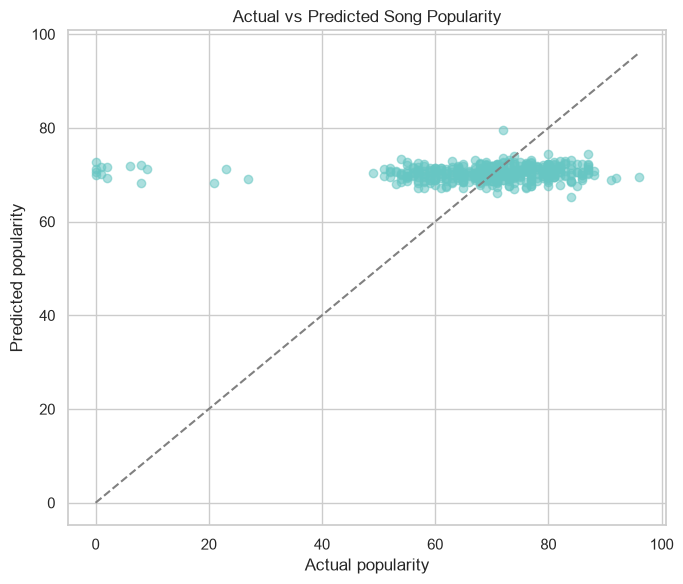

In [12]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, popularity_pred, alpha=0.55, color='#67C6C3')

minimum = min(y_test.min(), popularity_pred.min())
maximum = max(y_test.max(), popularity_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], '--', color='gray')

plt.title('Actual vs Predicted Song Popularity')
plt.xlabel('Actual popularity')
plt.ylabel('Predicted popularity')
plt.tight_layout()
plt.savefig('reports/figures/04_models/popularity_actual_vs_predicted.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/04_models/popularity_actual_vs_predicted.svg', bbox_inches='tight')
plt.show()

### A4. Residual plot

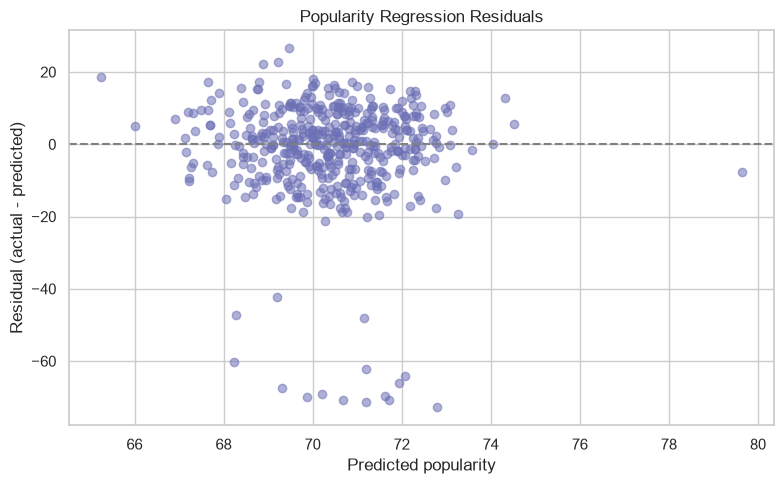

In [13]:
residuals = y_test - popularity_pred

plt.figure(figsize=(8, 5))
plt.scatter(popularity_pred, residuals, alpha=0.55, color='#6C70B5')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Popularity Regression Residuals')
plt.xlabel('Predicted popularity')
plt.ylabel('Residual (actual - predicted)')
plt.tight_layout()
plt.savefig('reports/figures/04_models/popularity_residuals.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/04_models/popularity_residuals.svg', bbox_inches='tight')
plt.show()

### A5. Standardized regression coefficients

Because the model uses standardized inputs, the coefficient sizes can be compared more fairly across features.

In [14]:
coefficients = pd.DataFrame({
    'feature': audio_features,
    'coefficient': popularity_model.named_steps['model'].coef_
})

coefficients['absolute_coefficient'] = coefficients['coefficient'].abs()
coefficients = coefficients.sort_values('absolute_coefficient', ascending=True)

coefficients[['feature', 'coefficient']]

,feature,coefficient
4,mode,-0.030989
5,speechiness,-0.041474
7,instrumentalness,-0.059705
1,energy,-0.159594
0,danceability,0.174531
6,acousticness,0.185306
8,liveness,0.216514
10,tempo,-0.422700
3,loudness,0.474745
12,time_signature,-0.477474


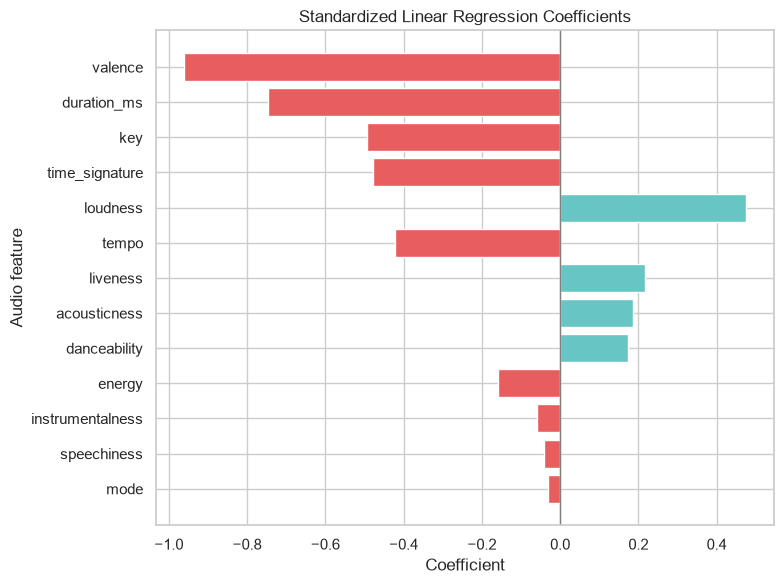

In [15]:
plt.figure(figsize=(8, 6))

bar_colors = np.where(coefficients['coefficient'] >= 0, '#67C6C3', '#E85D5D')
plt.barh(coefficients['feature'], coefficients['coefficient'], color=bar_colors)
plt.axvline(0, color='gray', linewidth=1)
plt.title('Standardized Linear Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Audio feature')
plt.tight_layout()
plt.savefig('reports/figures/04_models/popularity_coefficients.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/04_models/popularity_coefficients.svg', bbox_inches='tight')
plt.show()

# Part B - Mood Classification

`mood_label` was created directly from **valence** and **energy** in Phase 2. Therefore these two columns are deliberately excluded here. Otherwise the classifier would simply learn the rule that created the answer.

In [16]:
mood_features = [
    'danceability', 'key', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'tempo', 'duration_ms', 'time_signature'
]

# One row per track prevents repeated genre rows from leaking across the split.
mood_data = genre.drop_duplicates(subset='track_id').copy()

X_mood = mood_data[mood_features]
y_mood = mood_data['mood_label']

print('Mood model rows:', len(mood_data))
print()
print('Mood distribution:')
print(y_mood.value_counts())

Mood model rows: 89741

Mood distribution:
mood_label
Euphoric       33221
Aggressive     30211
Melancholic    19030
Peaceful        7279
Name: count, dtype: int64


In [17]:
X_mood_train, X_mood_test, y_mood_train, y_mood_test = train_test_split(
    X_mood, y_mood,
    test_size=0.20,
    random_state=42,
    stratify=y_mood
)

print('Training rows:', len(X_mood_train))
print('Testing rows:', len(X_mood_test))

Training rows: 71792
Testing rows: 17949


### B1. Baseline mood classifier

In [18]:
baseline_mood = DummyClassifier(strategy='most_frequent')
baseline_mood.fit(X_mood_train, y_mood_train)

baseline_mood_pred = baseline_mood.predict(X_mood_test)

print('Baseline accuracy:', accuracy_score(y_mood_test, baseline_mood_pred))
print('Baseline macro F1:', f1_score(
    y_mood_test, baseline_mood_pred, average='macro', zero_division=0
))

Baseline accuracy: 0.370215610897543
Baseline macro F1: 0.13509392534764578


### B2. Choose a Decision Tree size

A small Grid Search checks only a few tree sizes. This is still the same Decision Tree model, but it helps avoid choosing the depth randomly. The score used is **macro F1**, so all four mood classes matter.

In [19]:
mood_grid = {
    'max_depth': [5, 8, 12],
    'min_samples_leaf': [5, 15]
}

mood_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=mood_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=2
)

mood_search.fit(X_mood_train, y_mood_train)

print('Best settings:', mood_search.best_params_)
print('Best cross-validation macro F1:', mood_search.best_score_)

Best settings: {'max_depth': 12, 'min_samples_leaf': 15}
Best cross-validation macro F1: 0.59631834887717


In [20]:
mood_model = mood_search.best_estimator_
mood_pred = mood_model.predict(X_mood_test)

mood_accuracy = accuracy_score(y_mood_test, mood_pred)
mood_precision = precision_score(y_mood_test, mood_pred, average='macro', zero_division=0)
mood_recall = recall_score(y_mood_test, mood_pred, average='macro', zero_division=0)
mood_f1 = f1_score(y_mood_test, mood_pred, average='macro', zero_division=0)

print('Accuracy:', mood_accuracy)
print('Macro precision:', mood_precision)
print('Macro recall:', mood_recall)
print('Macro F1:', mood_f1)

Accuracy: 0.6521254665998105
Macro precision: 0.6194731592334108
Macro recall: 0.5979868230716957
Macro F1: 0.6057672794806078


In [21]:
mood_report = pd.DataFrame(
    classification_report(
        y_mood_test,
        mood_pred,
        output_dict=True,
        zero_division=0
    )
).T

mood_report

,precision,recall,f1-score,support
Aggressive,0.655602,0.643992,0.649745,6042.000000
Euphoric,0.640649,0.683070,0.661180,6645.000000
Melancholic,0.718179,0.733841,0.725926,3806.000000
Peaceful,0.463462,0.331044,0.386218,1456.000000
accuracy,0.652125,0.652125,0.652125,0.652125
macro avg,0.619473,0.597987,0.605767,17949.000000
weighted avg,0.647749,0.652125,0.648755,17949.000000


### B3. Mood confusion matrix

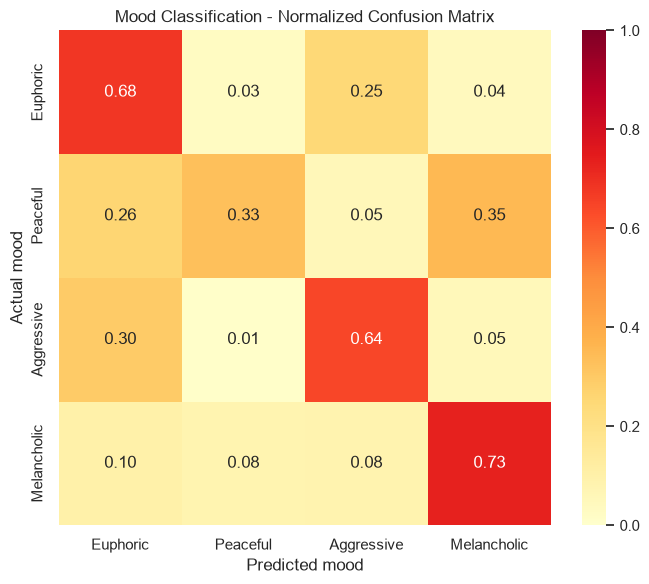

In [22]:
mood_matrix = confusion_matrix(
    y_mood_test,
    mood_pred,
    labels=mood_order,
    normalize='true'
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    mood_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    xticklabels=mood_order,
    yticklabels=mood_order,
    vmin=0,
    vmax=1
)
plt.title('Mood Classification - Normalized Confusion Matrix')
plt.xlabel('Predicted mood')
plt.ylabel('Actual mood')
plt.tight_layout()
plt.savefig('reports/figures/04_models/mood_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/04_models/mood_confusion_matrix.svg', bbox_inches='tight')
plt.show()

### B4. Decision Tree preview

The final tree can be deeper than this picture. We only display the first few levels so the decision rules stay readable.

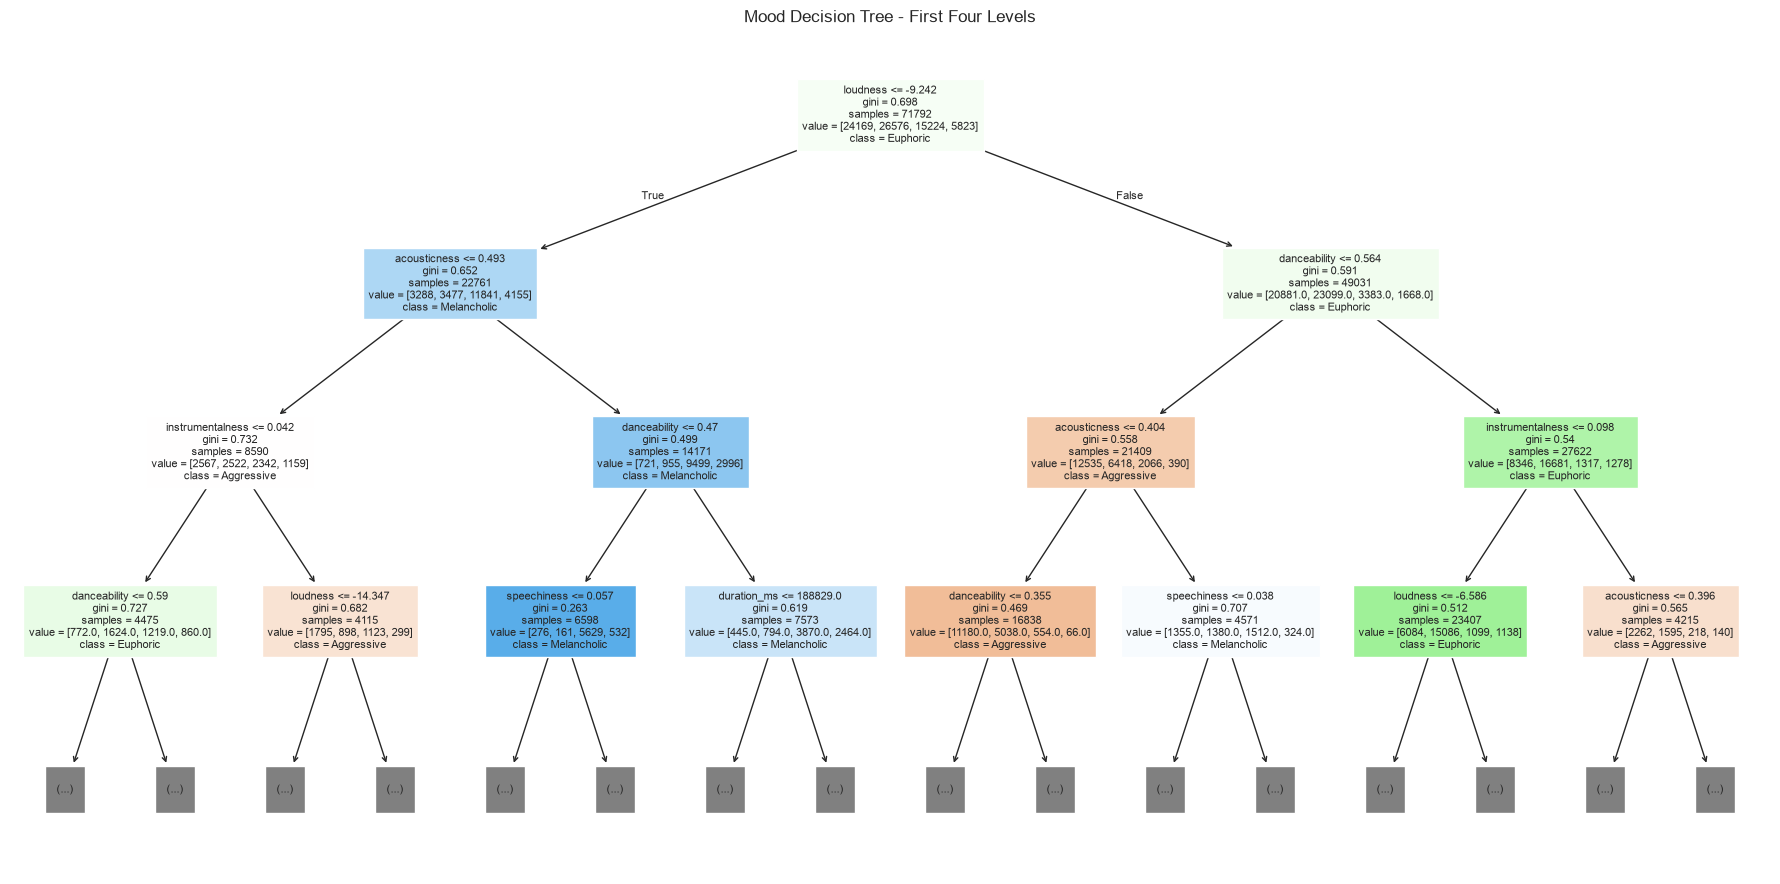

In [23]:
plt.figure(figsize=(18, 9))
plot_tree(
    mood_model,
    feature_names=mood_features,
    class_names=mood_model.classes_,
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title('Mood Decision Tree - First Four Levels')
plt.tight_layout()
plt.savefig('reports/figures/04_models/mood_decision_tree.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/04_models/mood_decision_tree.svg', bbox_inches='tight')
plt.show()

### B5. Mood feature importance

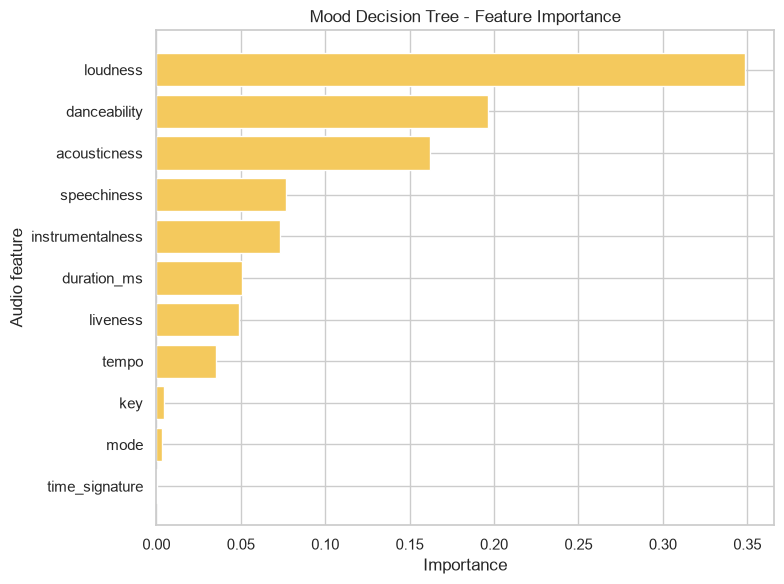

In [24]:
mood_importance = pd.DataFrame({
    'feature': mood_features,
    'importance': mood_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(mood_importance['feature'], mood_importance['importance'], color='#F4C95D')
plt.title('Mood Decision Tree - Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Audio feature')
plt.tight_layout()
plt.savefig('reports/figures/04_models/mood_feature_importance.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/04_models/mood_feature_importance.svg', bbox_inches='tight')
plt.show()

# Part C - Genre Classification

The main genre experiment uses only tracks that have **exactly one genre label**. This avoids giving one identical track two conflicting target labels.

In [25]:
genre_data = genre[genre['is_single_genre_track'] == True].copy()

# The Phase 1/2 data already has one row per track+genre.
# For single-genre tracks this also means one row per track.
genre_data = genre_data.drop_duplicates(subset='track_id')

X_genre = genre_data[audio_features].astype('float32')
y_genre = genre_data['track_genre']

print('Genre model rows:', len(genre_data))
print('Genre classes:', y_genre.nunique())
print()
print('Smallest class size:', y_genre.value_counts().min())
print('Largest class size:', y_genre.value_counts().max())

Genre model rows: 73442
Genre classes: 112

Smallest class size: 72
Largest class size: 999


In [26]:
X_genre_train, X_genre_test, y_genre_train, y_genre_test = train_test_split(
    X_genre, y_genre,
    test_size=0.20,
    random_state=42,
    stratify=y_genre
)

print('Training rows:', len(X_genre_train))
print('Testing rows:', len(X_genre_test))

Training rows: 58753
Testing rows: 14689


### C1. Baseline genre classifier

In [27]:
baseline_genre = DummyClassifier(strategy='most_frequent')
baseline_genre.fit(X_genre_train, y_genre_train)

baseline_genre_pred = baseline_genre.predict(X_genre_test)

print('Baseline accuracy:', accuracy_score(y_genre_test, baseline_genre_pred))
print('Baseline macro F1:', f1_score(
    y_genre_test, baseline_genre_pred, average='macro', zero_division=0
))

Baseline accuracy: 0.01361563074409422
Baseline macro F1: 0.00023987027815357455


### C2. Random Forest

The proposal uses 100 trees. We keep those 100 trees, while limiting tree depth and very small leaves so the model stays practical on a normal laptop and does not grow unnecessarily large.

In [28]:
genre_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=16,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=2
)

genre_model.fit(X_genre_train, y_genre_train)
genre_pred = genre_model.predict(X_genre_test)
genre_probabilities = genre_model.predict_proba(X_genre_test)

In [29]:
genre_accuracy = accuracy_score(y_genre_test, genre_pred)
genre_macro_f1 = f1_score(y_genre_test, genre_pred, average='macro', zero_division=0)
genre_weighted_f1 = f1_score(y_genre_test, genre_pred, average='weighted', zero_division=0)
genre_top3 = top_k_accuracy_score(
    y_genre_test,
    genre_probabilities,
    k=3,
    labels=genre_model.classes_
)

print('Accuracy:', genre_accuracy)
print('Macro F1:', genre_macro_f1)
print('Weighted F1:', genre_weighted_f1)
print('Top-3 accuracy:', genre_top3)

Accuracy: 0.34406698890326093
Macro F1: 0.2942505445626037
Weighted F1: 0.32153079255297384
Top-3 accuracy: 0.5278099257948125


In [30]:
genre_report = pd.DataFrame(
    classification_report(
        y_genre_test,
        genre_pred,
        output_dict=True,
        zero_division=0
    )
).T

# Show a small part here; the complete report is saved later.
genre_report.head(15)

,precision,recall,f1-score,support
acoustic,0.222222,0.182927,0.200669,164.0
afrobeat,0.293233,0.206349,0.242236,189.0
alt-rock,0.000000,0.000000,0.000000,32.0
alternative,0.950000,0.612903,0.745098,31.0
ambient,0.352273,0.216783,0.268398,143.0
anime,0.388889,0.053030,0.093333,132.0
black-metal,0.396226,0.480000,0.434109,175.0
bluegrass,0.240240,0.410256,0.303030,195.0
blues,0.428571,0.038961,0.071429,77.0
brazil,0.000000,0.000000,0.000000,56.0


### C3. Genre feature importance

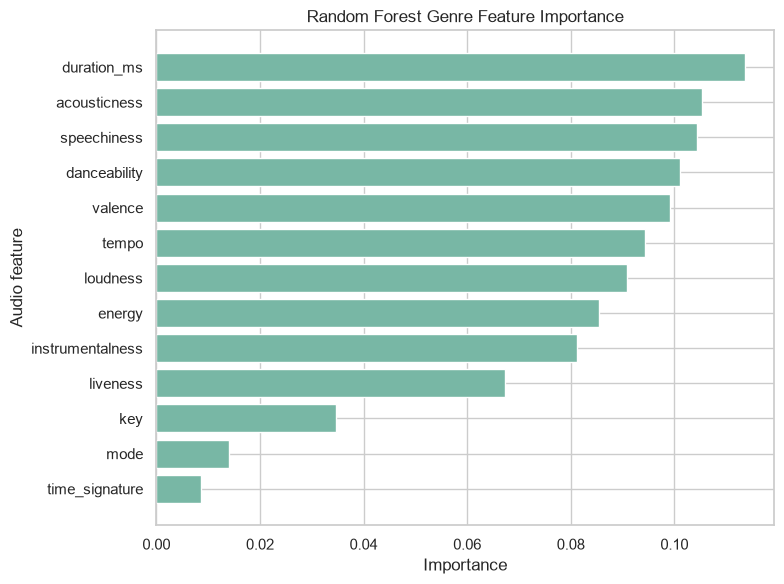

In [31]:
genre_importance = pd.DataFrame({
    'feature': audio_features,
    'importance': genre_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(genre_importance['feature'], genre_importance['importance'], color='#78B7A5')
plt.title('Random Forest Genre Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Audio feature')
plt.tight_layout()
plt.savefig('reports/figures/04_models/genre_feature_importance.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/04_models/genre_feature_importance.svg', bbox_inches='tight')
plt.show()

### C4. Selected-genre confusion matrix

A full confusion matrix with more than 100 genre labels is unreadable. We reuse the eight representative genres from Phase 3. If the model predicts another genre for one of these tracks, that prediction is shown as `other`.

In [32]:
selected_genres = [
    'pop', 'rock', 'hip-hop', 'jazz',
    'classical', 'country', 'edm', 'acoustic'
]

genre_confusion = pd.DataFrame({
    'actual': y_genre_test.reset_index(drop=True),
    'predicted': pd.Series(genre_pred)
})

genre_confusion = genre_confusion[
    genre_confusion['actual'].isin(selected_genres)
].copy()

genre_confusion['predicted_display'] = np.where(
    genre_confusion['predicted'].isin(selected_genres),
    genre_confusion['predicted'],
    'other'
)

genre_confusion_table = pd.crosstab(
    genre_confusion['actual'],
    genre_confusion['predicted_display'],
    normalize='index'
)

genre_confusion_table = genre_confusion_table.reindex(
    index=selected_genres,
    columns=selected_genres + ['other'],
    fill_value=0
)

genre_confusion_table

predicted_display,pop,rock,hip-hop,jazz,classical,country,edm,acoustic,other
actual,,,,,,,,,
pop,0.256098,0.000000,0.012195,0.000000,0.000000,0.036585,0.0,0.036585,0.658537
rock,0.000000,0.363636,0.000000,0.000000,0.000000,0.000000,0.0,0.018182,0.618182
hip-hop,0.000000,0.000000,0.222222,0.000000,0.000000,0.000000,0.0,0.000000,0.777778
jazz,0.000000,0.000000,0.000000,0.644444,0.000000,0.000000,0.0,0.000000,0.355556
classical,0.000000,0.000000,0.000000,0.000000,0.488722,0.000000,0.0,0.000000,0.511278
country,0.000000,0.000000,0.000000,0.000000,0.000000,0.537572,0.0,0.040462,0.421965
edm,0.000000,0.000000,0.000000,0.000000,0.000000,0.038462,0.0,0.000000,0.961538
acoustic,0.000000,0.000000,0.000000,0.006098,0.006098,0.036585,0.0,0.182927,0.768293


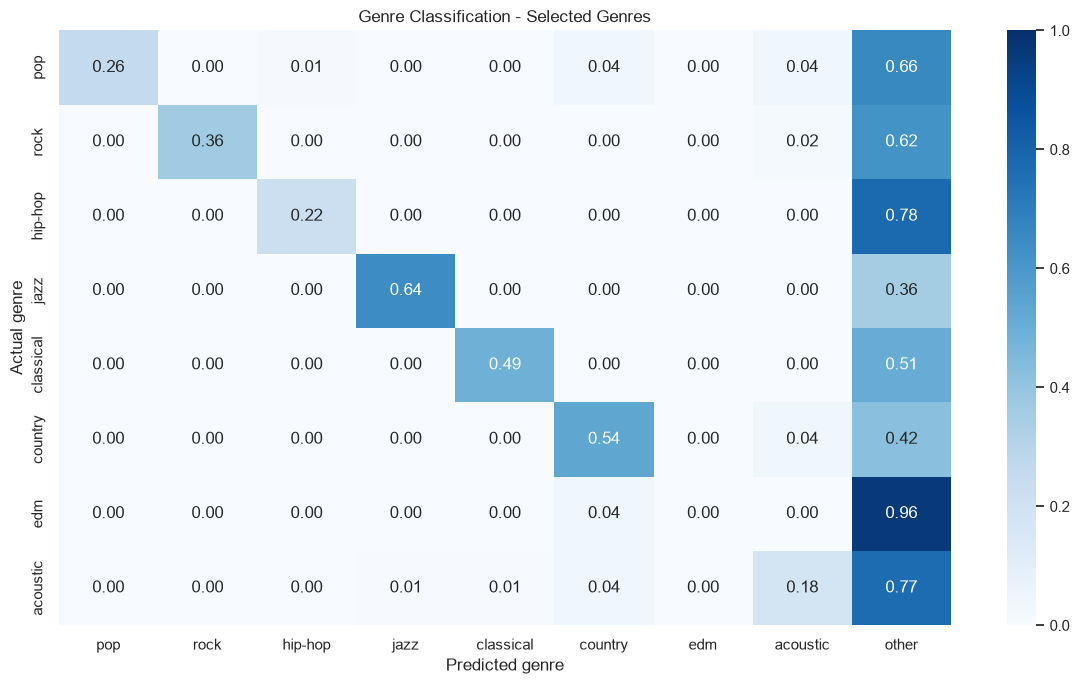

In [33]:
plt.figure(figsize=(12, 7))
sns.heatmap(
    genre_confusion_table,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0,
    vmax=1
)
plt.title('Genre Classification - Selected Genres')
plt.xlabel('Predicted genre')
plt.ylabel('Actual genre')
plt.tight_layout()
plt.savefig('reports/figures/04_models/genre_confusion_selected.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/04_models/genre_confusion_selected.svg', bbox_inches='tight')
plt.show()

### C5. Best and hardest genre classes

In [34]:
genre_class_rows = genre_report.loc[genre_model.classes_].copy()

print('Highest F1 genre classes:')
display(genre_class_rows.sort_values('f1-score', ascending=False).head(10))

print('Lowest F1 genre classes:')
display(genre_class_rows.sort_values('f1-score', ascending=True).head(10))

Highest F1 genre classes:


,precision,recall,f1-score,support
comedy,0.912791,0.792929,0.848649,198.0
sleep,0.791469,0.839196,0.814634,199.0
jazz,0.892308,0.644444,0.748387,90.0
alternative,0.950000,0.612903,0.745098,31.0
drum-and-bass,0.630137,0.745946,0.683168,185.0
grindcore,0.606299,0.781726,0.682927,197.0
dance,0.723684,0.617978,0.666667,89.0
electro,0.853659,0.507246,0.636364,69.0
study,0.471649,0.915000,0.622449,200.0
hardstyle,0.465385,0.675978,0.551253,179.0


Lowest F1 genre classes:


,precision,recall,f1-score,support
alt-rock,0.000000,0.000000,0.000000,32.0
brazil,0.000000,0.000000,0.000000,56.0
edm,0.000000,0.000000,0.000000,26.0
reggae,0.000000,0.000000,0.000000,17.0
punk-rock,0.000000,0.000000,0.000000,49.0
punk,0.000000,0.000000,0.000000,42.0
reggaeton,0.000000,0.000000,0.000000,14.0
metal,0.000000,0.000000,0.000000,30.0
hard-rock,0.166667,0.013158,0.024390,76.0
electronic,0.222222,0.014388,0.027027,139.0


## 3. Compare the models with their baselines

In [35]:
model_metrics = pd.DataFrame([
    {
        'task': 'Popularity regression',
        'model': 'DummyRegressor (mean)',
        'MAE': mean_absolute_error(y_test, baseline_popularity_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, baseline_popularity_pred)),
        'R2': r2_score(y_test, baseline_popularity_pred)
    },
    {
        'task': 'Popularity regression',
        'model': 'LinearRegression',
        'MAE': popularity_mae,
        'RMSE': popularity_rmse,
        'R2': popularity_r2
    },
    {
        'task': 'Mood classification',
        'model': 'DummyClassifier',
        'Accuracy': accuracy_score(y_mood_test, baseline_mood_pred),
        'Macro F1': f1_score(y_mood_test, baseline_mood_pred, average='macro', zero_division=0)
    },
    {
        'task': 'Mood classification',
        'model': 'DecisionTreeClassifier',
        'Accuracy': mood_accuracy,
        'Macro Precision': mood_precision,
        'Macro Recall': mood_recall,
        'Macro F1': mood_f1
    },
    {
        'task': 'Genre classification',
        'model': 'DummyClassifier',
        'Accuracy': accuracy_score(y_genre_test, baseline_genre_pred),
        'Macro F1': f1_score(y_genre_test, baseline_genre_pred, average='macro', zero_division=0)
    },
    {
        'task': 'Genre classification',
        'model': 'RandomForestClassifier',
        'Accuracy': genre_accuracy,
        'Macro F1': genre_macro_f1,
        'Weighted F1': genre_weighted_f1,
        'Top-3 Accuracy': genre_top3
    }
])

model_metrics

,task,model,MAE,RMSE,R2,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Top-3 Accuracy
0,Popularity regression,DummyRegressor (mean),9.152396,14.514568,-0.012562,NaN,NaN,NaN,NaN,NaN,NaN
1,Popularity regression,LinearRegression,9.085448,14.525854,-0.014137,NaN,NaN,NaN,NaN,NaN,NaN
2,Mood classification,DummyClassifier,NaN,NaN,NaN,0.370216,0.135094,NaN,NaN,NaN,NaN
3,Mood classification,DecisionTreeClassifier,NaN,NaN,NaN,0.652125,0.605767,0.619473,0.597987,NaN,NaN
4,Genre classification,DummyClassifier,NaN,NaN,NaN,0.013616,0.000240,NaN,NaN,NaN,NaN
5,Genre classification,RandomForestClassifier,NaN,NaN,NaN,0.344067,0.294251,NaN,NaN,0.321531,0.52781


## 4. Save reports and trained models

In [36]:
# Save tables used in the report.
model_metrics.to_csv('reports/tables/model_metrics.csv', index=False)
coefficients[['feature', 'coefficient']].to_csv(
    'reports/tables/popularity_coefficients.csv', index=False
)
mood_report.to_csv('reports/tables/mood_classification_report.csv')
genre_report.to_csv('reports/tables/genre_classification_report.csv')
genre_confusion_table.to_csv('reports/tables/genre_confusion_selected.csv')

# Compress model files so the Random Forest does not take unnecessary disk space.
joblib.dump(popularity_model, 'models/popularity_regression.joblib', compress=3)
joblib.dump(mood_model, 'models/mood_classifier.joblib', compress=3)
joblib.dump(genre_model, 'models/genre_classifier.joblib', compress=3)

print('Tables and model files saved.')

Tables and model files saved.


### Model metadata

The metadata files record exactly which features were used and what performance was measured. This will make the later backend handoff safer.

In [37]:
trained_at = datetime.now().isoformat(timespec='seconds')

popularity_metadata = {
    'model_name': 'popularity_regression',
    'model_version': '1.0.0',
    'trained_at': trained_at,
    'target': 'popularity',
    'features': audio_features,
    'training_rows': len(X_train),
    'test_rows': len(X_test),
    'random_state': 42,
    'metrics': {
        'mae': float(popularity_mae),
        'mse': float(popularity_mse),
        'rmse': float(popularity_rmse),
        'r2': float(popularity_r2)
    },
    'sklearn_version': sklearn.__version__
}

mood_metadata = {
    'model_name': 'mood_classifier',
    'model_version': '1.0.0',
    'trained_at': trained_at,
    'target': 'mood_label',
    'features': mood_features,
    'training_rows': len(X_mood_train),
    'test_rows': len(X_mood_test),
    'random_state': 42,
    'best_parameters': mood_search.best_params_,
    'metrics': {
        'accuracy': float(mood_accuracy),
        'macro_precision': float(mood_precision),
        'macro_recall': float(mood_recall),
        'macro_f1': float(mood_f1)
    },
    'sklearn_version': sklearn.__version__
}

genre_metadata = {
    'model_name': 'genre_classifier',
    'model_version': '1.0.0',
    'trained_at': trained_at,
    'target': 'track_genre',
    'features': audio_features,
    'training_rows': len(X_genre_train),
    'test_rows': len(X_genre_test),
    'class_count': int(y_genre.nunique()),
    'random_state': 42,
    'parameters': {
        'n_estimators': 100,
        'max_depth': 16,
        'min_samples_leaf': 2
    },
    'metrics': {
        'accuracy': float(genre_accuracy),
        'macro_f1': float(genre_macro_f1),
        'weighted_f1': float(genre_weighted_f1),
        'top_3_accuracy': float(genre_top3)
    },
    'sklearn_version': sklearn.__version__
}

for name, metadata in [
    ('popularity_regression', popularity_metadata),
    ('mood_classifier', mood_metadata),
    ('genre_classifier', genre_metadata)
]:
    with open(f'models/metadata/{name}.json', 'w') as file:
        json.dump(metadata, file, indent=4)

print('Model metadata saved.')

Model metadata saved.


## 5. Check that the saved models load correctly

In [38]:
loaded_popularity = joblib.load('models/popularity_regression.joblib')
loaded_mood = joblib.load('models/mood_classifier.joblib')
loaded_genre = joblib.load('models/genre_classifier.joblib')

print('Popularity model prediction:', loaded_popularity.predict(X_test.iloc[[0]])[0])
print('Mood model prediction:', loaded_mood.predict(X_mood_test.iloc[[0]])[0])
print('Genre model prediction:', loaded_genre.predict(X_genre_test.iloc[[0]])[0])
print()
print('All three saved models loaded and predicted successfully.')

Popularity model prediction: 72.24521101864916
Mood model prediction: Melancholic
Genre model prediction: mandopop

All three saved models loaded and predicted successfully.
